# MNIST Dataset:

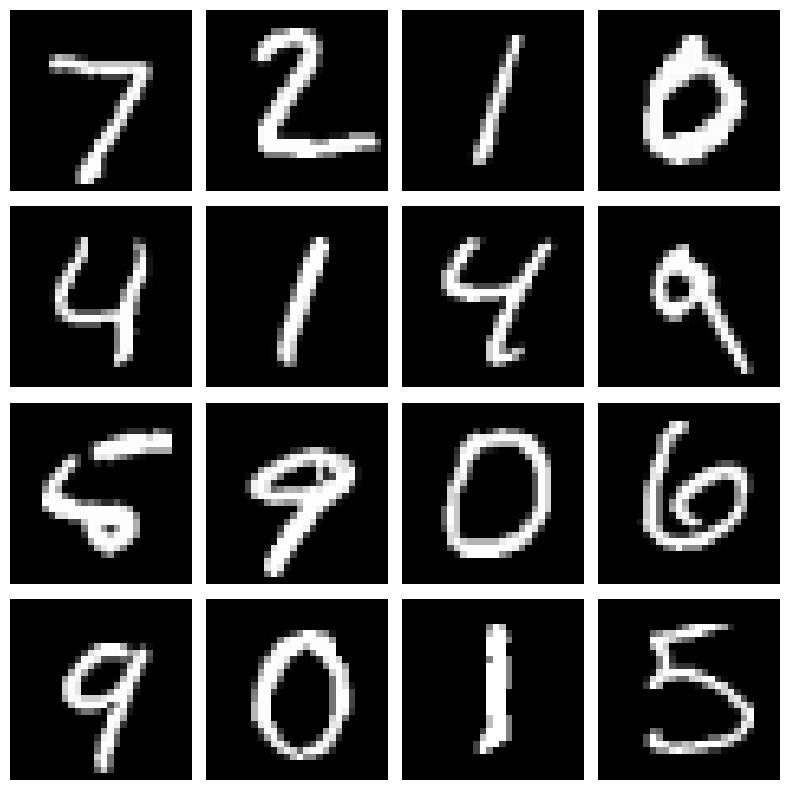

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD
from keras.utils import to_categorical

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Print 16 images from the MNIST dataset with their predictions
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
axes = axes.ravel()

for i in range(16):
    axes[i].imshow(x_test[i].reshape(28, 28), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Epoch 1/10


/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/python3.14/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7000 - loss: 1.2282 - val_accuracy: 0.8487 - val_loss: 0.6760
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8572 - loss: 0.5774 - val_accuracy: 0.8801 - val_loss: 0.4748
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8793 - loss: 0.4569 - val_accuracy: 0.8927 - val_loss: 0.4039
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8902 - loss: 0.4042 - val_accuracy: 0.9008 - val_loss: 0.3666
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8963 - loss: 0.3733 - val_accuracy: 0.9053 - val_loss: 0.3434
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9013 - loss: 0.3519 - val_accuracy: 0.9108 - val_loss: 0.3268
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9054 - loss: 0.3358 - val_accuracy: 0.9128 - val_loss: 0.3139
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9090 - loss: 0.3229 - val_accuracy: 0.9155 - val_

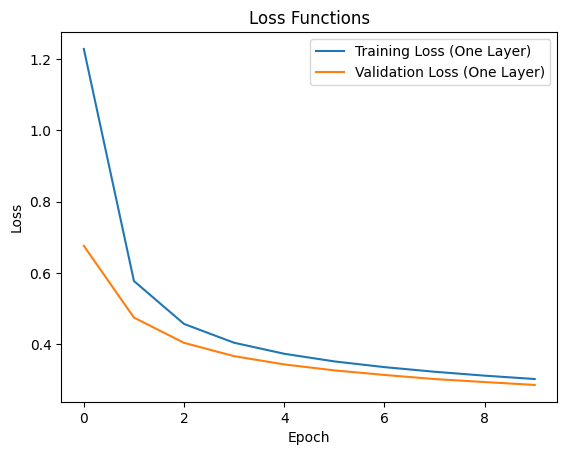

In [2]:
# Preprocess the data
x_train = x_train.reshape(-1, 784) / 255.0
x_test = x_test.reshape(-1, 784) / 255.0
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# Define a neural network with one layer
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(784,)))
model.add(Dense(10, activation='softmax'))

# Compile and train the model
model.compile(optimizer=SGD(learning_rate=0.01), loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, batch_size=128, epochs=10, validation_data=(x_test, y_test))

# Plot the loss function for training and validation sets
plt.plot(history.history['loss'], label='Training Loss (One Layer)')
plt.plot(history.history['val_loss'], label='Validation Loss (One Layer)')
plt.title('Loss Functions')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 771us/step


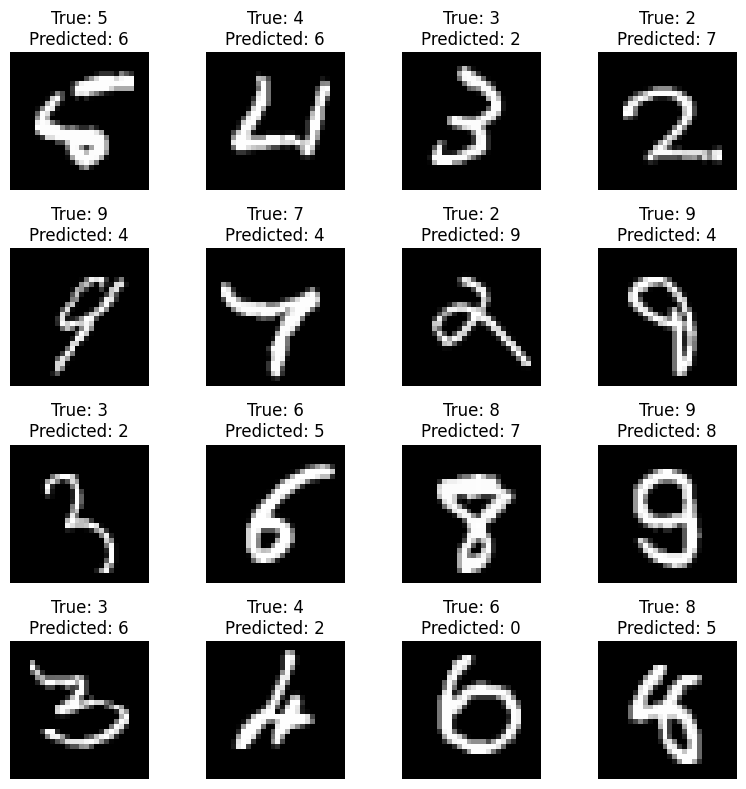

In [3]:
# Predict on the test set
predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)
y_trues = np.argmax(y_test, axis=1)

# Find misclassification examples
misclassified_indices = np.where(predicted_labels != y_trues)[0]

# Print the first 16 misclassification examples
num_examples = 16
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flatten()):
    image_index = misclassified_indices[i]
    image = x_test[image_index].reshape(28, 28)
    true_label = y_trues[image_index]
    predicted_label = predicted_labels[image_index]
    ax.imshow(image, cmap='gray')
    ax.set_title(f'True: {true_label}\nPredicted: {predicted_label}')
    ax.axis('off')

plt.tight_layout()
plt.show()

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7533 - loss: 1.1347 - val_accuracy: 0.8786 - val_loss: 0.5268
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8857 - loss: 0.4482 - val_accuracy: 0.9038 - val_loss: 0.3668
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9033 - loss: 0.3553 - val_accuracy: 0.9146 - val_loss: 0.3133
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9121 - loss: 0.3147 - val_accuracy: 0.9208 - val_loss: 0.2866
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9186 - loss: 0.2889 - val_accuracy: 0.9247 - val_loss: 0.2676
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9243 - loss: 0.2691 - val_accuracy: 0.9295 - val_loss: 0.2522
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9288 - loss: 0.2533 - val_accuracy: 0.9347 - val_loss: 0.2379
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9326 - loss: 0.2397 - val_accuracy: 0.

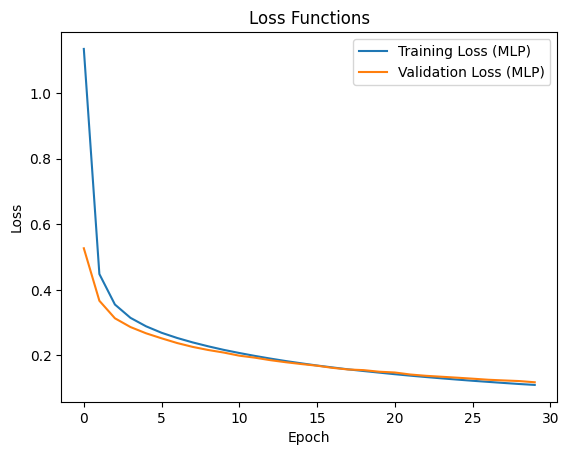

In [4]:
# Define a multi-layer perceptron (MLP) with more parameters
mlp_model = Sequential()
mlp_model.add(Dense(512, activation='relu', input_shape=(784,)))
mlp_model.add(Dense(512, activation='relu'))
mlp_model.add(Dense(10, activation='softmax'))

# Compile and train the MLP model
mlp_model.compile(optimizer=SGD(learning_rate=0.01), loss='categorical_crossentropy', metrics=['accuracy'])
mlp_history = mlp_model.fit(x_train, y_train, batch_size=128, epochs=30, validation_data=(x_test, y_test))

plt.plot(mlp_history.history['loss'], label='Training Loss (MLP)')
plt.plot(mlp_history.history['val_loss'], label='Validation Loss (MLP)')
plt.title('Loss Functions')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


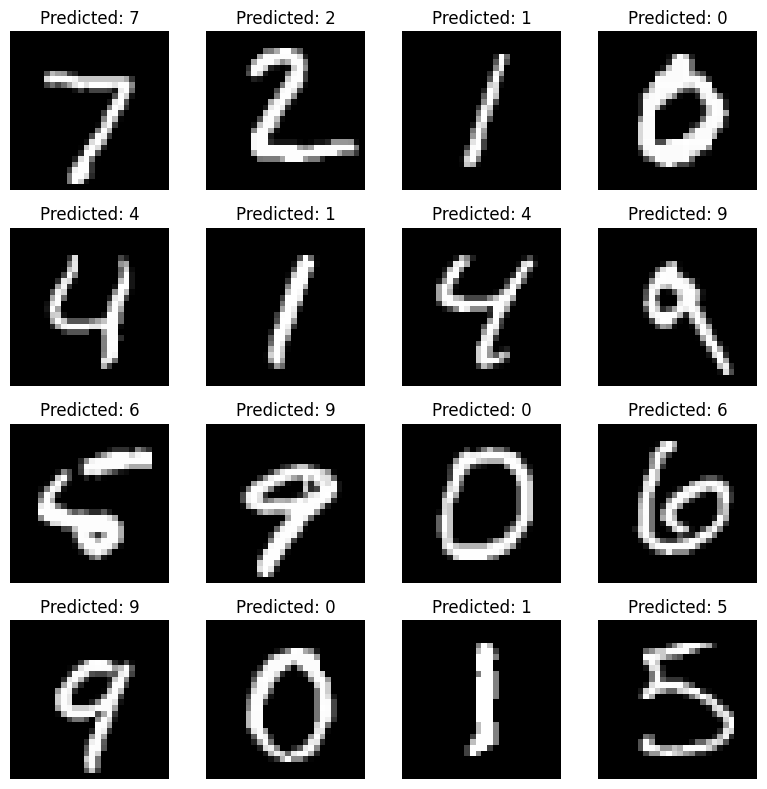

In [5]:
# Print 16 images from the MNIST dataset with their predictions
predictions = model.predict(x_test[:16])
predicted_labels = np.argmax(predictions, axis=1)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
axes = axes.ravel()

for i in range(16):
    axes[i].imshow(x_test[i].reshape(28, 28), cmap='gray')
    axes[i].set_title(f"Predicted: {predicted_labels[i]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Dataset de noticias:

In [6]:
import numpy as np
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
import pandas as pd
import nltk
nltk.download('stopwords')

df_educacion = pd.read_csv("../datasets/noticias_educacion_sample.csv")
df_educacion['clase'] = 0
df_politica = pd.read_csv("../datasets/noticias_politica_sample.csv")
df_politica['clase'] = 1
df_deportes = pd.read_csv("../datasets/noticias_deportes_sample.csv")
df_deportes['clase'] = 2
df_economia = pd.read_csv("../datasets/noticias_economia_sample.csv")
df_economia['clase'] = 3
df = pd.concat([df_educacion, df_politica, df_deportes, df_economia]).dropna().reset_index()

# Split the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(df.content, df.clase, test_size=0.2, random_state=42)

# Download the NLTK Spanish stopwords if you haven't already
spanish_stopwords = nltk.corpus.stopwords.words('spanish')

# Create TF-IDF vectorizer
vectorizer = TfidfVectorizer(max_features=2000, stop_words=spanish_stopwords, ngram_range=(1,5), lowercase=True)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Train Random Forest classifier
rf_model = RandomForestClassifier()
rf_model.fit(X_train_tfidf, y_train)

# Make predictions with Random Forest
rf_predictions = rf_model.predict(X_test_tfidf)
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f"Random Forest Accuracy: {rf_accuracy}")

# Train a neural network with more layers and neurons
model = Sequential()
model.add(Dense(128, activation='relu', input_dim=X_train_tfidf.shape[1]))
model.add(Dense(256, activation='relu'))
model.add(Dense(len(df.clase), activation='softmax'))
model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train_tfidf.toarray(), y_train, batch_size=128, epochs=10, validation_data=(X_test_tfidf.toarray(), y_test))

# Make predictions with the neural network
nn_predictions = np.argmax(model.predict(X_test_tfidf.toarray()), axis=-1)
nn_accuracy = accuracy_score(y_test, nn_predictions)
print(f"Neural Network Accuracy: {nn_accuracy}")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/davidzarruk/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Random Forest Accuracy: 0.9250645994832042
Epoch 1/10
 8/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1547 - loss: 7.5416     

/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/python3.14/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2568 - loss: 7.4143 - val_accuracy: 0.2506 - val_loss: 6.8942
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2419 - loss: 5.4386 - val_accuracy: 0.2377 - val_loss: 2.2988
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4101 - loss: 1.4978 - val_accuracy: 0.4522 - val_loss: 1.3184
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5091 - loss: 1.2450 - val_accuracy: 0.6537 - val_loss: 1.1522
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7678 - loss: 1.0437 - val_accuracy: 0.8501 - val_loss: 0.9054
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8823 - loss: 0.7370 - val_accuracy: 0.8811 - val_loss: 0.6099
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9056 - loss: 0.4808 - val_accuracy: 0.9044 - val_loss: 0.3941
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9463 - loss: 0.3006 - val_accuracy: 0.9328 - val_loss: 0.2843


# Overfitting and regularization:

/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/python3.14/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


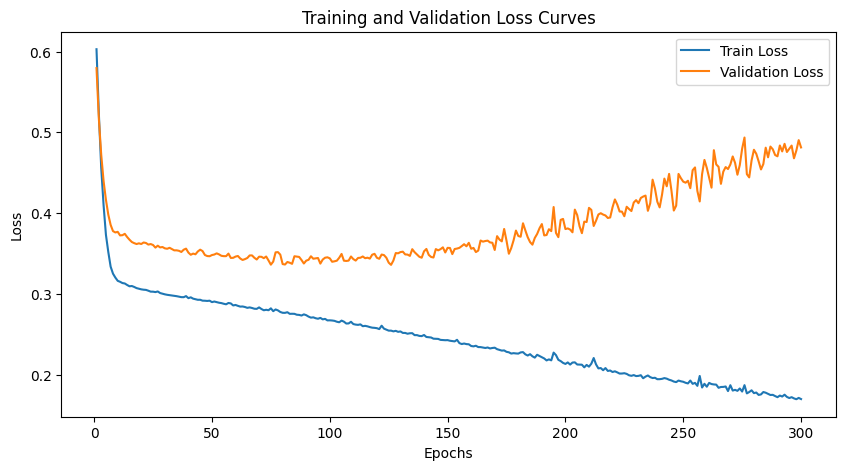

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import History

# Generate a synthetic dataset
X, y = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0, n_classes=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the MLP model
model = Sequential()
model.add(Dense(100, input_dim=2, activation='relu'))
model.add(Dense(100, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam')

# Train the MLP model with increased epochs
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=300, verbose=0)

# Extract training and validation losses from the history object
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot the loss curves
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Train Loss')
plt.plot(range(1, len(val_loss) + 1), val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.show()


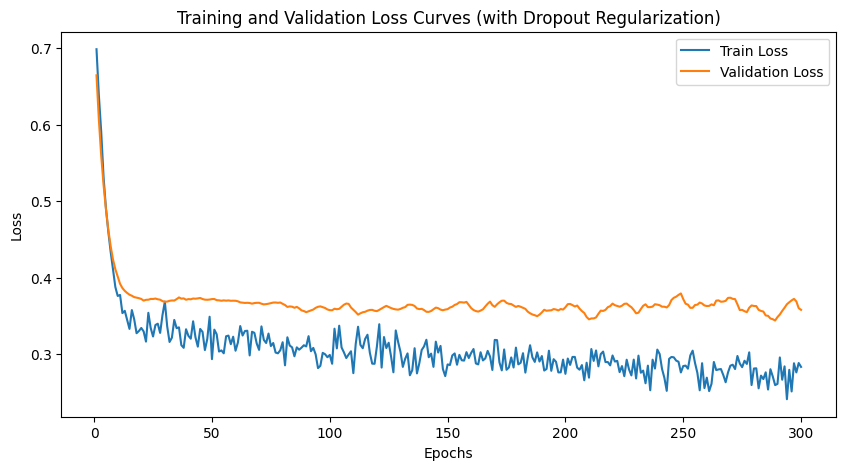

In [8]:
from keras.layers import Dense, Dropout

# Define the MLP model with dropout regularization
model = Sequential()
model.add(Dense(100, input_dim=2, activation='relu'))
model.add(Dropout(0.5))  # Dropout layer with dropout rate of 0.5
model.add(Dense(100, activation='relu'))
model.add(Dropout(0.5))  # Dropout layer with dropout rate of 0.5
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam')

# Train the MLP model with increased epochs
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=300, verbose=0)

# Extract training and validation losses from the history object
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot the loss curves
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Train Loss')
plt.plot(range(1, len(val_loss) + 1), val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curves (with Dropout Regularization)')
plt.legend()
plt.show()

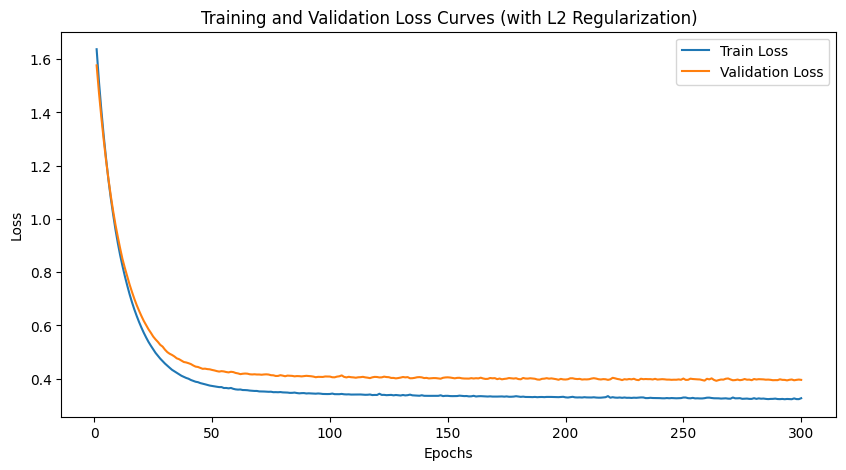

In [9]:
from keras import regularizers

# Define the MLP model with L2 regularization
model = Sequential()
model.add(Dense(100, input_dim=2, activation='relu', kernel_regularizer=regularizers.l2(0.01)))
model.add(Dense(100, activation='relu', kernel_regularizer=regularizers.l2(0.01)))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam')

# Train the MLP model with increased epochs
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=300, verbose=0)

# Extract training and validation losses from the history object
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot the loss curves
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Train Loss')
plt.plot(range(1, len(val_loss) + 1), val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curves (with L2 Regularization)')
plt.legend()
plt.show()

# CIFAR Dataset

CIFAR classes: 1. Airplane, 2.Automobile, 3.Bird, 4.Cat, 5.Deer, 6.Dog, 7.Frog, 8.Horse, 9.Ship, 10.Truck

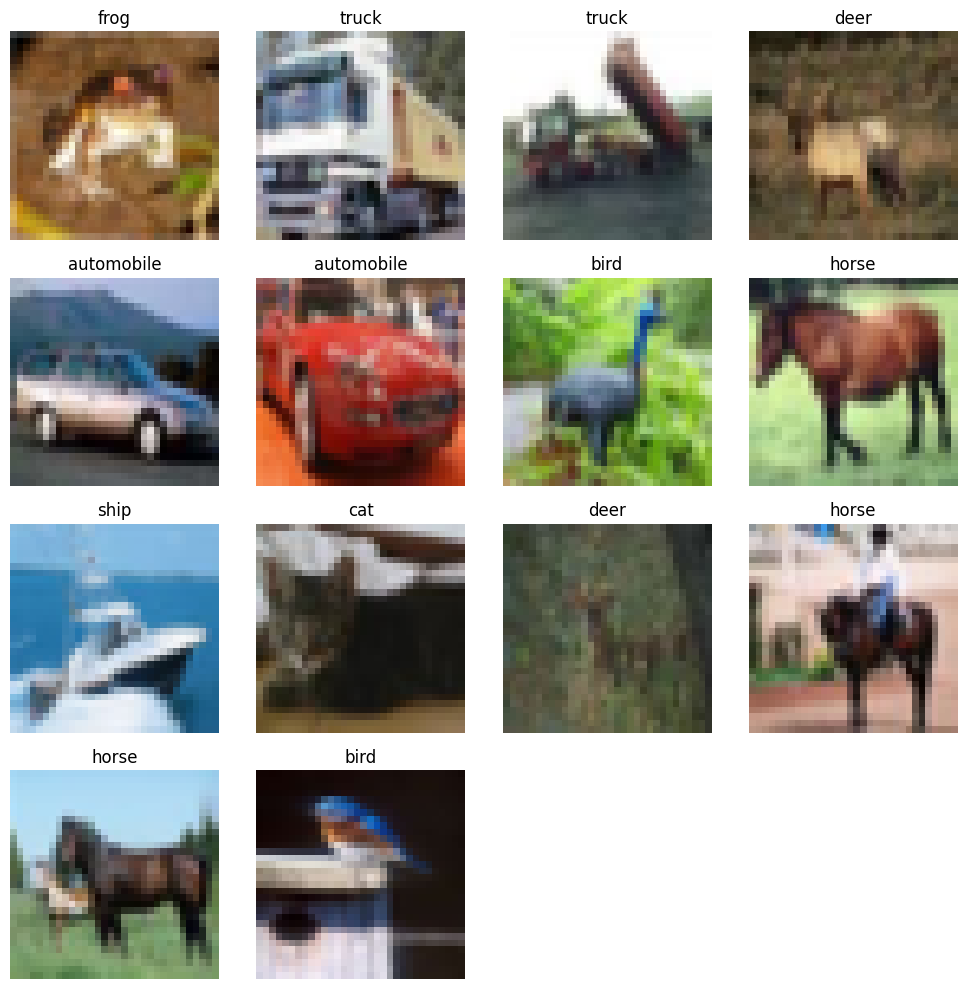

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import cifar10

# Load the CIFAR-10 dataset
(X_train, y_train), (_, _) = cifar10.load_data()

# Define the class labels
class_labels = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Plot the example images
plt.figure(figsize=(10, 10))
for i in range(14):
    image = X_train[i]
    label = class_labels[y_train[i][0]]
    
    plt.subplot(4, 4, i+1)
    plt.imshow(image)
    plt.title(label)
    plt.axis('off')

plt.tight_layout()
plt.show()


In [11]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import to_categorical
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Preprocess the data
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
y_train_nn = to_categorical(y_train, num_classes=10)
y_test_nn = to_categorical(y_test, num_classes=10)

# Reshape the input data
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

# Create a neural network model
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(3072,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train_nn, epochs=10, batch_size=32, validation_data=(X_test, y_test_nn))

# Evaluate the model
_, nn_accuracy = model.evaluate(X_test, y_test_nn)
print("Neural Network Accuracy:", nn_accuracy)

# Make predictions using the Neural Network
nn_pred = model.predict(X_test)
nn_pred_labels = np.argmax(nn_pred, axis=1)

# Train a Random Forest classifier
rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
rf.fit(X_train, y_train.ravel())

# Make predictions using Random Forest
rf_pred = rf.predict(X_test)

# Evaluate the Random Forest classifier
rf_accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_accuracy)

# Calculate precision, recall, and F1-score for each class
target_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']
nn_report = classification_report(np.argmax(y_test_nn, axis=1), nn_pred_labels, target_names=target_names)
rf_report = classification_report(y_test, rf_pred, target_names=target_names)

print("Neural Network Classification Report:")
print(nn_report)

print("Random Forest Classification Report:")
print(rf_report)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.3210 - loss: 1.8746 - val_accuracy: 0.3421 - val_loss: 1.8316
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.3856 - loss: 1.7120 - val_accuracy: 0.3986 - val_loss: 1.6775
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.4093 - loss: 1.6477 - val_accuracy: 0.4015 - val_loss: 1.6608
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.4203 - loss: 1.6185 - val_accuracy: 0.4230 - val_loss: 1.6081
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.4315 - loss: 1.5847 - val_accuracy: 0.4421 - val_loss: 1.5710
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.4369 - loss: 1.5694 - val_accuracy: 0.4296 - val_loss: 1.5804
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.4447 - loss: 1.5474 - val_accuracy: 0.4242 - val_loss: 1.6026
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.4478 - loss: 1.5414 - 